# Exploratory Data Analysis #

#### Basic stats ####

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import glob
import gc

gc.collect()
sns.set_theme(style="whitegrid")

# Pick whichever sample you want to analyze
SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet"))


for path in SAMPLE_PATHS:
    print(f"\n{'=' * 60}")
    print(f"  {path}")
    print(f"{'=' * 60}")
    df = pd.read_parquet(path)
    print(f"  Reviews: {len(df):,}  |  Users: {df['user_id'].nunique():,}  |  Books: {df['parent_asin'].nunique():,}")
    if len(df)== 0:
        print("  Empty file")
        print(f"  {path}")
        continue

    n_users   = df["user_id"].nunique()
    n_books   = df["parent_asin"].nunique()
    n_reviews = len(df)

    print("=" * 50)
    print("       STATISTIQUES DE BASE DE L'ÉCHANTILLON")
    print("=" * 50)
    print(f"  Nombre total de reviews  : {n_reviews:>12,}")
    print(f"  Nombre d'utilisateurs    : {n_users:>12,}")
    print(f"  Nombre de livres (ASINs) : {n_books:>12,}")
    print(f"  Reviews / utilisateur    : {n_reviews / n_users:>12.1f}")
    print(f"  Reviews / livre          : {n_reviews / n_books:>12.1f}")
    print("=" * 50)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── 2a. Distribution of ratings ────────────────────────────────
    rating_counts = df["rating"].value_counts().sort_index()
    axes[0].bar(rating_counts.index, rating_counts.values, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Note (rating)")
    axes[0].set_ylabel("Nombre de reviews")
    axes[0].set_title("Distribution des notes")
    axes[0].set_xticks([1, 2, 3, 4, 5])
    for i, v in enumerate(rating_counts.values):
        axes[0].text(rating_counts.index[i], v + v * 0.02, f"{v:,}", ha="center", fontsize=9)

    # ── 2b. Distribution of reviews per user ───────────────────────
    reviews_per_user = df.groupby("user_id").size()
    axes[1].hist(reviews_per_user, bins=50, color="darkorange", edgecolor="white", log=True)
    axes[1].set_xlabel("Nombre de reviews par utilisateur")
    axes[1].set_ylabel("Nombre d'utilisateurs (log)")
    axes[1].set_title("Distribution des reviews par utilisateur")
    axes[1].axvline(reviews_per_user.mean(), color="red", linestyle="--", label=f"Moyenne: {reviews_per_user.mean():.1f}")
    axes[1].legend()

    # ── 2c. Distribution of reviews per book ───────────────────────
    reviews_per_book = df.groupby("parent_asin").size()
    axes[2].hist(reviews_per_book, bins=50, color="seagreen", edgecolor="white", log=True)
    axes[2].set_xlabel("Nombre de reviews par livre")
    axes[2].set_ylabel("Nombre de livres (log)")
    axes[2].set_title("Distribution des reviews par livre")
    axes[2].axvline(reviews_per_book.mean(), color="red", linestyle="--", label=f"Moyenne: {reviews_per_book.mean():.1f}")
    axes[2].legend()

    plt.tight_layout()
    plt.show()

    print("── Moyennes ──────────────────────────────────────")
    print(f"  Moyenne de reviews par utilisateur : {reviews_per_user.mean():.2f}")
    print(f"  Médiane de reviews par utilisateur : {reviews_per_user.median():.1f}")
    print(f"  Écart-type (utilisateur)           : {reviews_per_user.std():.2f}")
    print()
    print(f"  Moyenne de reviews par livre       : {reviews_per_book.mean():.2f}")
    print(f"  Médiane de reviews par livre       : {reviews_per_book.median():.1f}")
    print(f"  Écart-type (livre)                 : {reviews_per_book.std():.2f}")
    print()
    print(f"  Note moyenne globale               : {df['rating'].mean():.2f}")
    print(f"  Note médiane                       : {df['rating'].median():.1f}")

    # ── Top 10 utilisateurs les plus actifs ────────────────────────
    top_users = (
        df.groupby("user_id")
        .agg(
            nb_reviews=("rating", "size"),
            note_moyenne=("rating", "mean"),
            helpful_total=("helpful_vote", "sum"),
        )
        .sort_values("nb_reviews", ascending=False)
        .head(10)
    )
    top_users["note_moyenne"] = top_users["note_moyenne"].round(2)

    print("── Top 10 utilisateurs les plus actifs ───────────")
    print(top_users.to_string())
    print()

    # ── Top 10 livres les plus appréciés ──────────────────────────
    # (highest average rating with at least 10 reviews to avoid noise)
    MIN_REVIEWS_BOOK = 10
    book_stats = (
        df.groupby("parent_asin")
        .agg(
            nb_reviews=("rating", "size"),
            note_moyenne=("rating", "mean"),
            helpful_total=("helpful_vote", "sum"),
            titre_exemple=("title", "first"),
        )
    )
    qualified_books = book_stats[book_stats["nb_reviews"] >= MIN_REVIEWS_BOOK]

    top_liked = qualified_books.sort_values("note_moyenne", ascending=False).head(10)
    top_liked["note_moyenne"] = top_liked["note_moyenne"].round(2)

    print(f"── Top 10 livres les plus appréciés (>= {MIN_REVIEWS_BOOK} reviews) ──")
    print(top_liked[["titre_exemple", "nb_reviews", "note_moyenne", "helpful_total"]].to_string())
    print()

    # ── Top 10 livres les plus reviewés ───────────────────────────
    top_reviewed = book_stats.sort_values("nb_reviews", ascending=False).head(10)
    top_reviewed["note_moyenne"] = top_reviewed["note_moyenne"].round(2)

    print("── Top 10 livres les plus reviewés ──────────────")
    print(top_reviewed[["titre_exemple", "nb_reviews", "note_moyenne", "helpful_total"]].to_string())




  sample-cudf-claude/500k_sample_gpu_temporal.parquet


  Reviews: 856,620  |  Users: 18,097  |  Books: 330,285
       STATISTIQUES DE BASE DE L'ÉCHANTILLON
  Nombre total de reviews  :      856,620
  Nombre d'utilisateurs    :       18,097
  Nombre de livres (ASINs) :      330,285
  Reviews / utilisateur    :         47.3
  Reviews / livre          :          2.6

  sample-cudf-claude/sample_gpu_active_users.parquet
  Reviews: 2,442,267  |  Users: 50,000  |  Books: 1,042,030
       STATISTIQUES DE BASE DE L'ÉCHANTILLON
  Nombre total de reviews  :    2,442,267
  Nombre d'utilisateurs    :       50,000
  Nombre de livres (ASINs) :    1,042,030
  Reviews / utilisateur    :         48.8
  Reviews / livre          :          2.3

  sample-cudf-claude/sample_gpu_temporal.parquet
  Reviews: 200,000  |  Users: 186,203  |  Books: 152,591
       STATISTIQUES DE BASE DE L'ÉCHANTILLON
  Nombre total de reviews  :      200,000
  Nombre d'utilisateurs    :      186,203
  Nombre de livres (ASINs) :      152,591
  Reviews / utilisateur    :          1.1


#### Compare all samples ####

  sample-cudf-claude/500k_sample_gpu_temporal.parquet: 856620 rows, columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'year']
Loaded sample-cudf-claude/500k_sample_gpu_temporal: 856,620 reviews
  sample-cudf-claude/sample_gpu_active_users.parquet: 2442267 rows, columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Loaded sample-cudf-claude/sample_gpu_active_users: 2,442,267 reviews
  sample-cudf-rapids-24+/sampled_reviews.parquet: 2442267 rows, columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Loaded sample-cudf-rapids-24+/sampled_reviews: 2,442,267 reviews
  sample-cudf-rapids-24-/sampled_reviews.parquet: 2442267 rows, columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase']
Lo

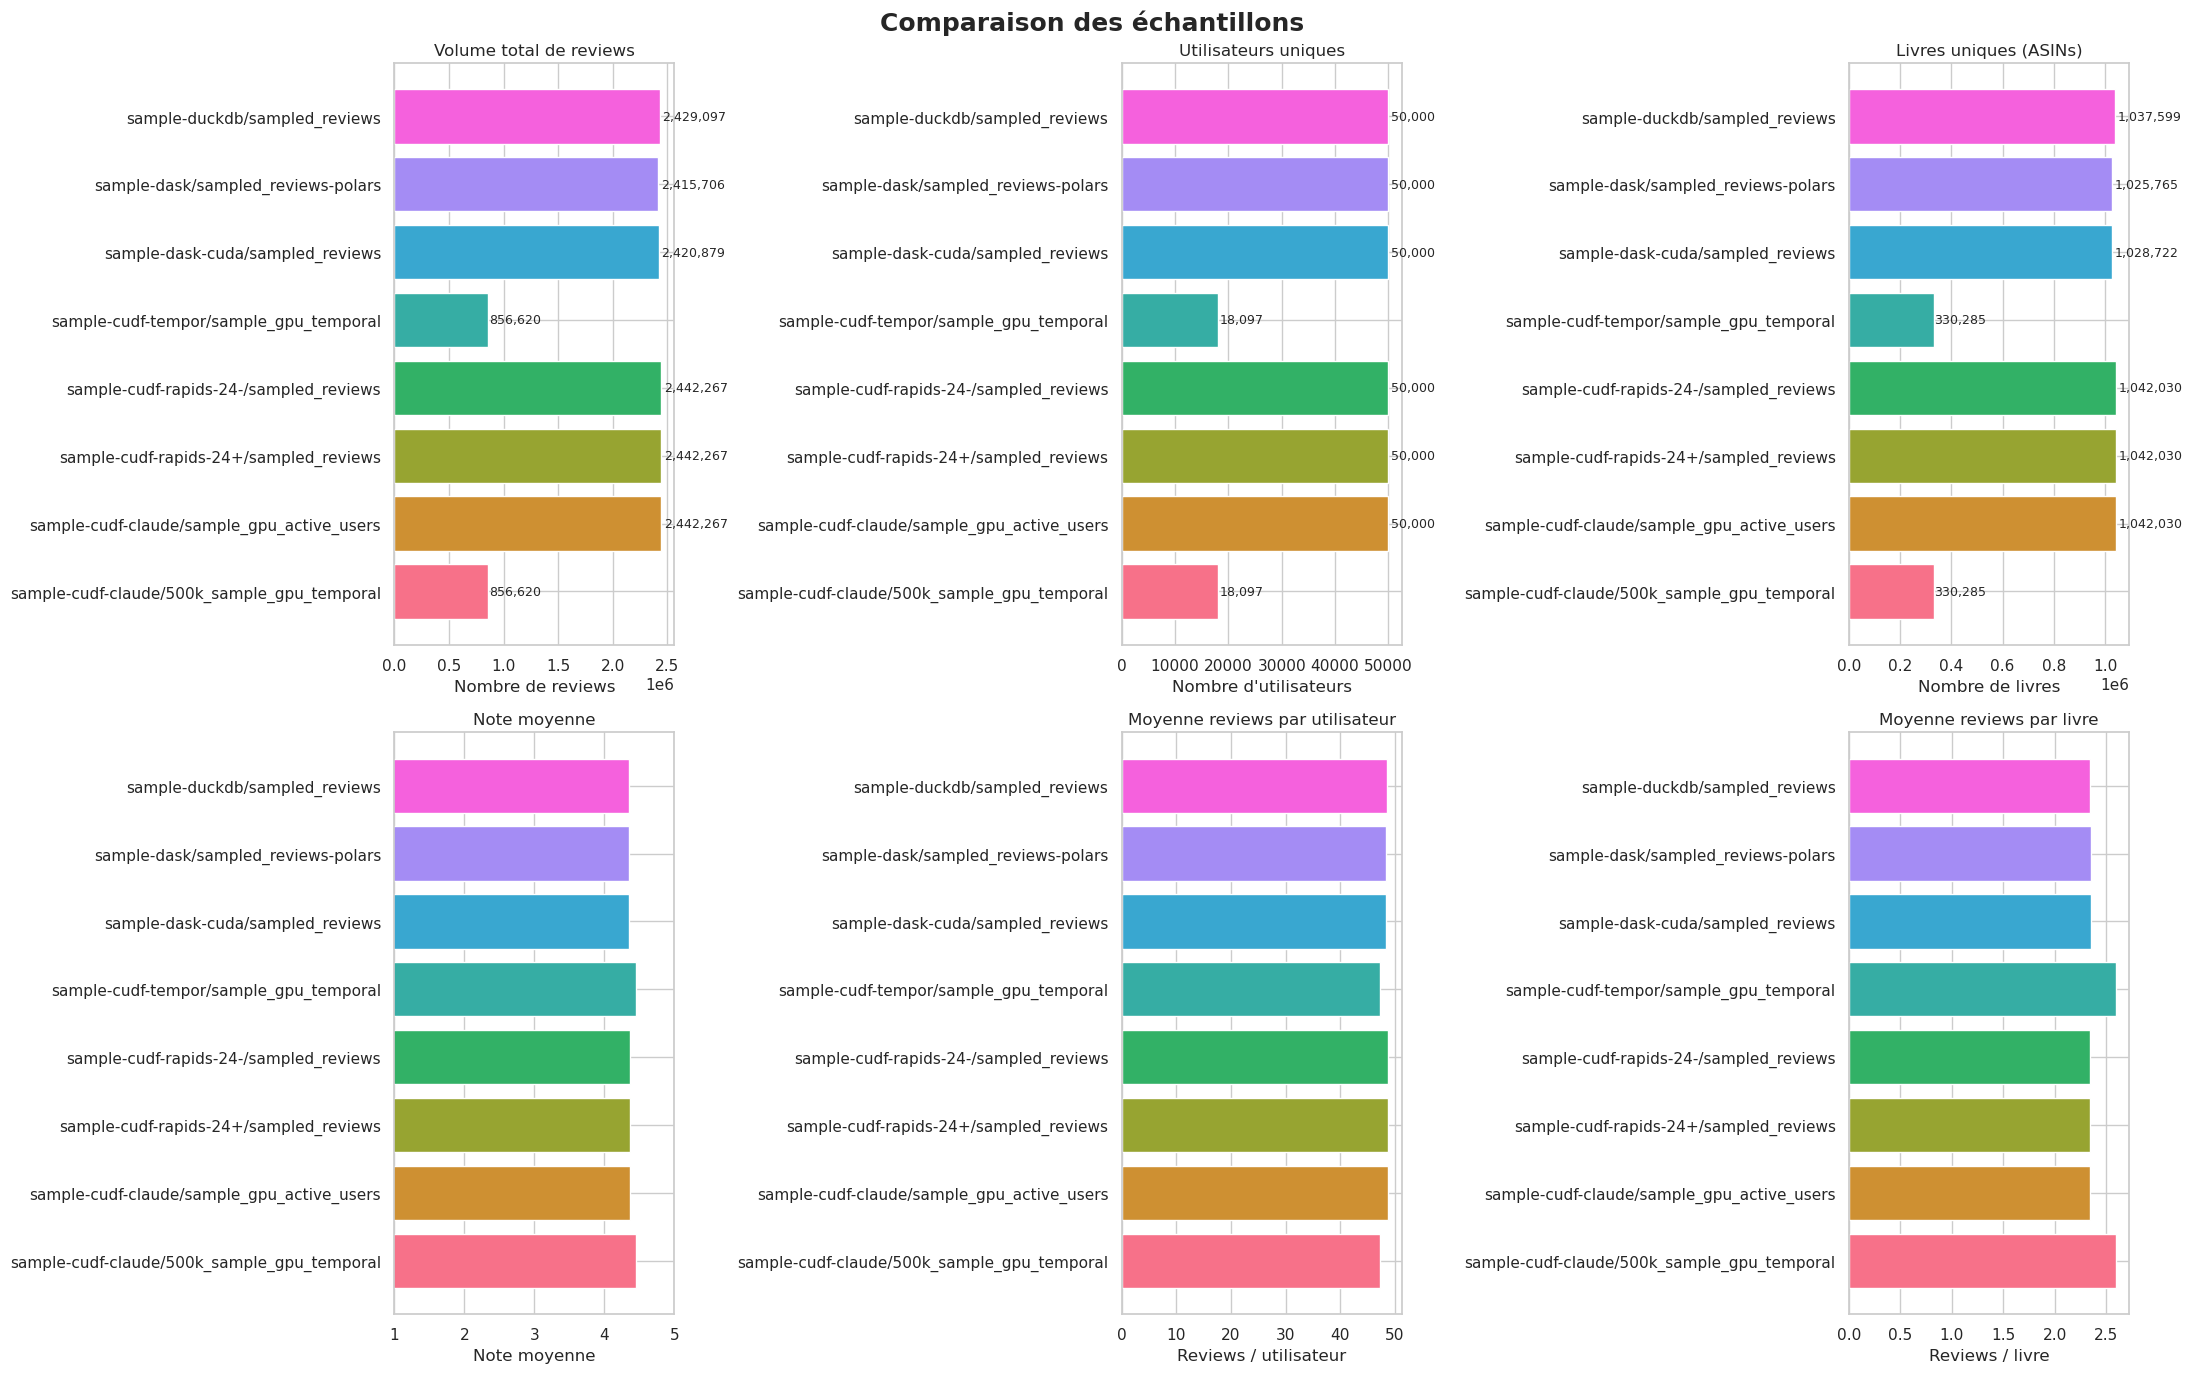

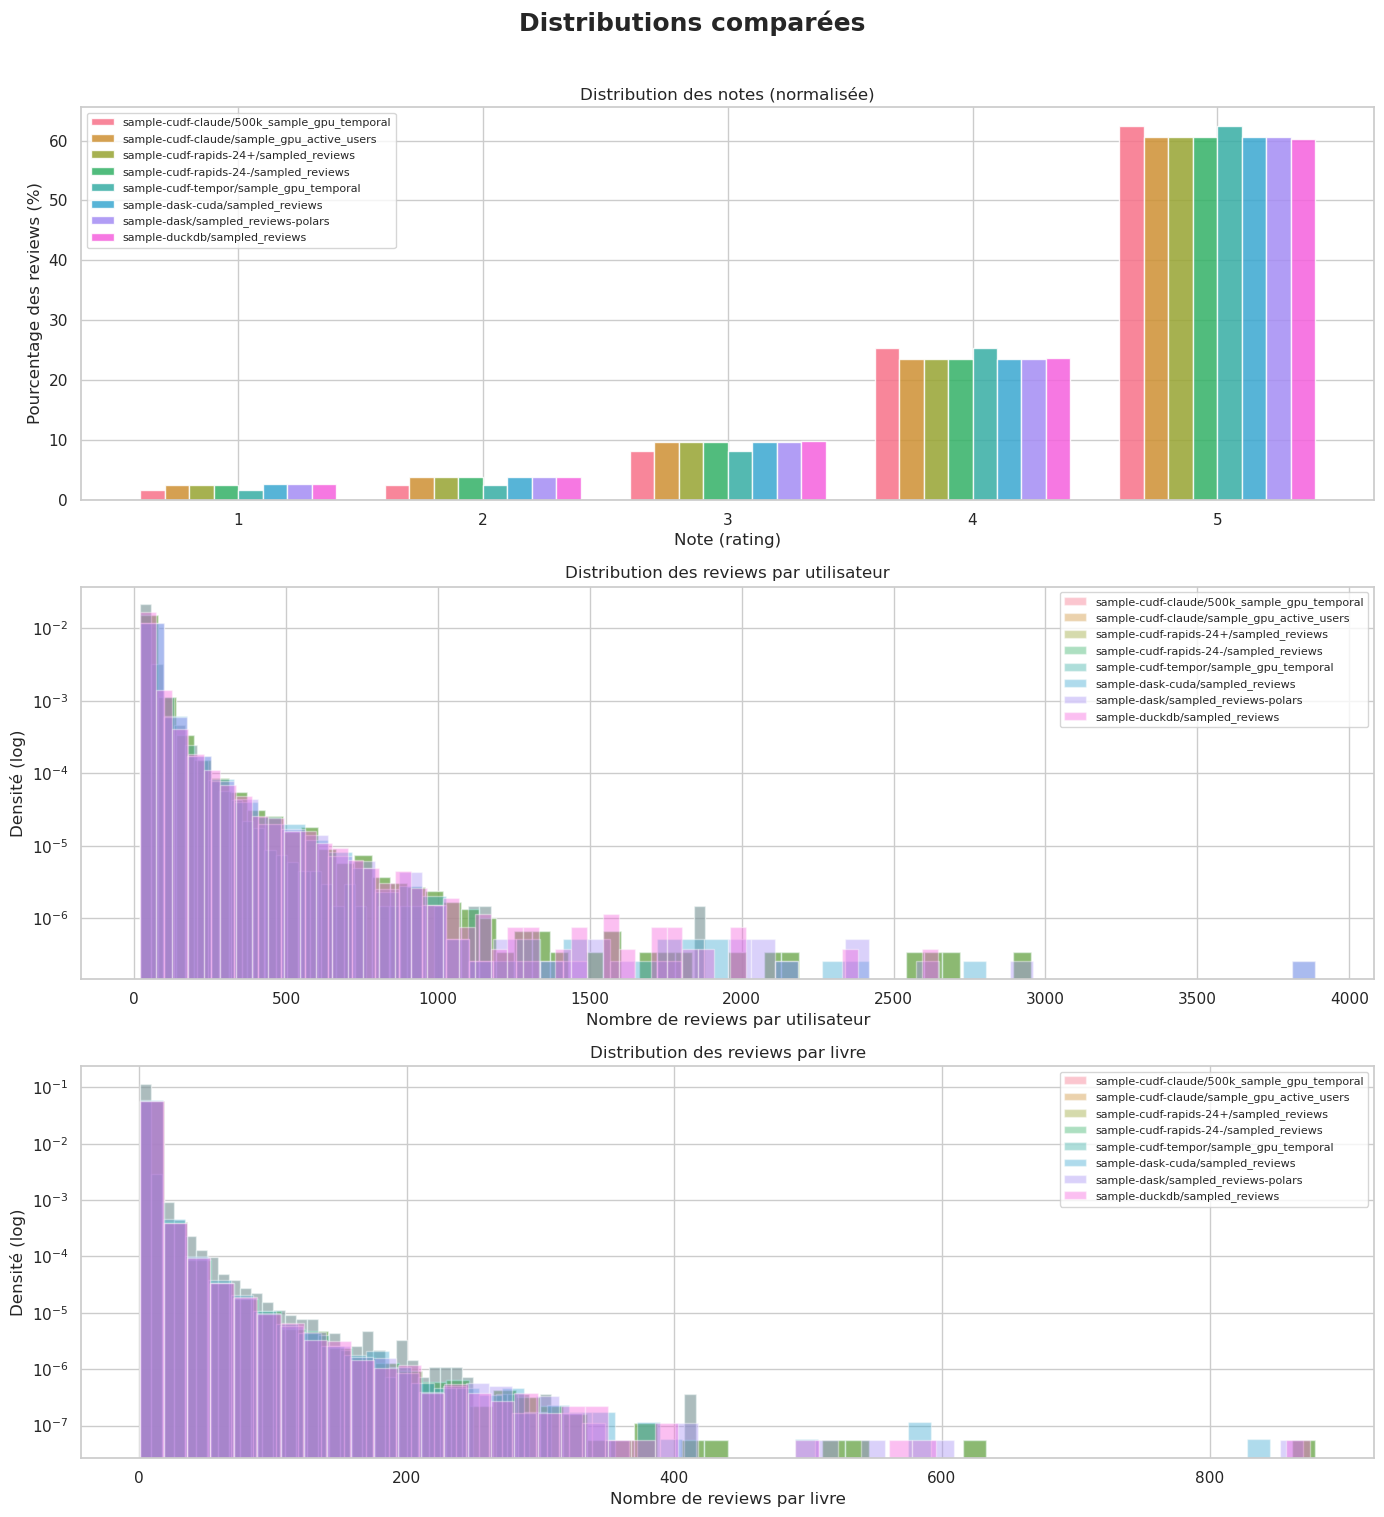

             Échantillon  Reviews  Utilisateurs  Livres  Note moy.  Rev/User  Rev/Livre
500k_sample_gpu_temporal   856620         18097  330285       4.45      47.3        2.6
 sample_gpu_active_users  2442267         50000 1042030       4.36      48.8        2.3
         sampled_reviews  2442267         50000 1042030       4.36      48.8        2.3
         sampled_reviews  2442267         50000 1042030       4.36      48.8        2.3
     sample_gpu_temporal   856620         18097  330285       4.45      47.3        2.6
         sampled_reviews  2420879         50000 1028722       4.36      48.4        2.4
  sampled_reviews-polars  2415706         50000 1025765       4.36      48.3        2.4
         sampled_reviews  2429097         50000 1037599       4.35      48.6        2.3


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from pathlib import Path
import os


sns.set_theme(style="whitegrid")

SAMPLE_PATHS = sorted(glob.glob("sample-*/*.parquet", recursive=False))

# Collect summary stats + per-sample distributions
summary = []
distributions = {}

for path in SAMPLE_PATHS:
    if os.path.getsize(path) < 1024:  # skip files smaller than 1KB
        print(f"  Skipping {path} (only {os.path.getsize(path)} bytes, likely corrupt)")
        continue
    df = pd.read_parquet(path)
    print(f"  {path}: {len(df)} rows, columns: {list(df.columns)}")    
    label = Path(path).parent.name  # e.g. "sample-cudf-claude"
    if len(df) == 0:
        continue

    reviews_per_user = df.groupby("user_id").size()
    reviews_per_book = df.groupby("parent_asin").size()

    summary.append({
        "sample": label,
        "file": Path(path).stem,
        "n_reviews": len(df),
        "n_users": df["user_id"].nunique(),
        "n_books": df["parent_asin"].nunique(),
        "avg_rating": df["rating"].mean(),
        "median_rating": df["rating"].median(),
        "avg_reviews_per_user": reviews_per_user.mean(),
        "median_reviews_per_user": reviews_per_user.median(),
        "avg_reviews_per_book": reviews_per_book.mean(),
        "median_reviews_per_book": reviews_per_book.median(),
        "rating_dist": df["rating"].value_counts().sort_index(),
    })

    distributions[f"{label}/{Path(path).stem}"] = {
        "reviews_per_user": reviews_per_user,
        "reviews_per_book": reviews_per_book,
        "ratings": df["rating"],
    }
    print(f"Loaded {label}/{Path(path).stem}: {len(df):,} reviews")

stats_df = pd.DataFrame(summary)
print(f"\n{len(stats_df)} samples loaded.")
stats_df[["sample", "file", "n_reviews", "n_users", "n_books", "avg_rating"]].to_string(index=False)
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle("Comparaison des échantillons", fontsize=18, fontweight="bold")

labels = stats_df["sample"] + "/" + stats_df["file"]
x = range(len(labels))
colors = sns.color_palette("husl", len(labels))

# Row 1, Col 1: Total reviews
axes[0, 0].barh(labels, stats_df["n_reviews"], color=colors)
axes[0, 0].set_xlabel("Nombre de reviews")
axes[0, 0].set_title("Volume total de reviews")
for i, v in enumerate(stats_df["n_reviews"]):
    axes[0, 0].text(v + v * 0.01, i, f"{v:,}", va="center", fontsize=9)

# Row 1, Col 2: Total users
axes[0, 1].barh(labels, stats_df["n_users"], color=colors)
axes[0, 1].set_xlabel("Nombre d'utilisateurs")
axes[0, 1].set_title("Utilisateurs uniques")
for i, v in enumerate(stats_df["n_users"]):
    axes[0, 1].text(v + v * 0.01, i, f"{v:,}", va="center", fontsize=9)

# Row 1, Col 3: Total books
axes[0, 2].barh(labels, stats_df["n_books"], color=colors)
axes[0, 2].set_xlabel("Nombre de livres")
axes[0, 2].set_title("Livres uniques (ASINs)")
for i, v in enumerate(stats_df["n_books"]):
    axes[0, 2].text(v + v * 0.01, i, f"{v:,}", va="center", fontsize=9)

# Row 2, Col 1: Avg rating
axes[1, 0].barh(labels, stats_df["avg_rating"], color=colors)
axes[1, 0].set_xlabel("Note moyenne")
axes[1, 0].set_title("Note moyenne")
axes[1, 0].set_xlim(1, 5)

# Row 2, Col 2: Avg reviews per user
axes[1, 1].barh(labels, stats_df["avg_reviews_per_user"], color=colors)
axes[1, 1].set_xlabel("Reviews / utilisateur")
axes[1, 1].set_title("Moyenne reviews par utilisateur")

# Row 2, Col 3: Avg reviews per book
axes[1, 2].barh(labels, stats_df["avg_reviews_per_book"], color=colors)
axes[1, 2].set_xlabel("Reviews / livre")
axes[1, 2].set_title("Moyenne reviews par livre")

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(3, 1, figsize=(14, 15))
fig.suptitle("Distributions comparées", fontsize=18, fontweight="bold", y=1.01)

sample_names = list(distributions.keys())
colors = sns.color_palette("husl", len(sample_names))

# Row 1: Rating distributions (grouped bar chart)
width = 0.8 / len(sample_names)
for i, (name, data) in enumerate(distributions.items()):
    counts = data["ratings"].value_counts().sort_index()
    counts_pct = counts / counts.sum() * 100  # normalize to % for fair comparison
    offset = (i - len(sample_names) / 2) * width + width / 2
    axes[0].bar(counts_pct.index + offset, counts_pct.values, width=width,
                label=name, color=colors[i], edgecolor="white", alpha=0.85)
axes[0].set_xlabel("Note (rating)")
axes[0].set_ylabel("Pourcentage des reviews (%)")
axes[0].set_title("Distribution des notes (normalisée)")
axes[0].set_xticks([1, 2, 3, 4, 5])
axes[0].legend(fontsize=8, loc="upper left")

# Row 2: Reviews per user (overlaid histograms)
for i, (name, data) in enumerate(distributions.items()):
    axes[1].hist(data["reviews_per_user"], bins=50, color=colors[i],
                 alpha=0.4, label=name, log=True, density=True)
axes[1].set_xlabel("Nombre de reviews par utilisateur")
axes[1].set_ylabel("Densité (log)")
axes[1].set_title("Distribution des reviews par utilisateur")
axes[1].legend(fontsize=8)

# Row 3: Reviews per book (overlaid histograms)
for i, (name, data) in enumerate(distributions.items()):
    axes[2].hist(data["reviews_per_book"], bins=50, color=colors[i],
                 alpha=0.4, label=name, log=True, density=True)
axes[2].set_xlabel("Nombre de reviews par livre")
axes[2].set_ylabel("Densité (log)")
axes[2].set_title("Distribution des reviews par livre")
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


comparison = stats_df[[
    "file", "n_reviews", "n_users", "n_books",
    "avg_rating", "avg_reviews_per_user", "avg_reviews_per_book"
]].copy()
comparison.columns = [
    "Échantillon", "Reviews", "Utilisateurs", "Livres",
    "Note moy.", "Rev/User", "Rev/Livre"
]
comparison["Note moy."] = comparison["Note moy."].round(2)
comparison["Rev/User"] = comparison["Rev/User"].round(1)
comparison["Rev/Livre"] = comparison["Rev/Livre"].round(1)

print(comparison.to_string(index=False))

# Utilitaries to get correct sample #

#### Compile all partitioned parquets ####

In [ ]:
import glob
import os
import pandas as pd

all_parquets = sorted(glob.glob("sample-*/*.parquet"))

partitioned = [p for p in all_parquets if os.path.isdir(p)]
single_files = [p for p in all_parquets if os.path.isfile(p)]

print(f"Single files: {len(single_files)}")
print(f"Partitioned dirs: {len(partitioned)}")

for d in partitioned:
    out_path = d.rstrip("/") + "-compiled.parquet"
    print(f"Compiling {d} -> {out_path}")
    df = pd.read_parquet(d)
    df.to_parquet(out_path)
    print(f"  Done: {len(df):,} rows")

Single files: 12
Partitioned dirs: 2
Compiling sample-dask-cuda/sampled_reviews.parquet -> sample-dask-cuda/sampled_reviews.parquet-compiled.parquet
  Done: 2,420,879 rows
Compiling sample-dask/sampled_reviews-polars.parquet -> sample-dask/sampled_reviews-polars.parquet-compiled.parquet
  Done: 2,415,706 rows


#### Convert all jsonl to parquet ####

In [ ]:
import glob
import pandas as pd
import gc

# convert all jsonl to parquet ###
JSON_SAMPLE_PATHS = sorted(glob.glob("sample-*/*.jsonl", recursive=False))
for p in JSON_SAMPLE_PATHS:
    print(f"  {p}")
    if len(p) == 0:
        continue
    df = pd.read_json(p, lines=True)
    df.to_parquet(p.replace(".jsonl", ".parquet"))
del df
gc.collect()

# Cleaning up memory 
#

In [5]:
import gc

# 1. GPU cleanup (safe even if no GPU libs loaded)
try:
    import cupy as cp
    cp.get_default_memory_pool().free_all_blocks()
    cp.get_default_pinned_memory_pool().free_all_blocks()
except ImportError:
    pass

try:
    import rmm
    rmm.reinitialize()
except (ImportError, RuntimeError):
    pass

try:
    import torch
    torch.cuda.empty_cache()
except ImportError:
    pass

# 2. Close DuckDB connections
try:
    import duckdb
    con.close()       # adjust to your connection variable name
except:
    pass

# 3. Nuke user-defined variables
_keep = {'In', 'Out', 'get_ipython', 'exit', 'quit', 'open'}
for _name in list(globals()):
    if not _name.startswith('_') and _name not in _keep:
        del globals()[_name]

# 4. Force GC
import gc
gc.collect()

90637

In [ ]:
import IPython
IPython.Application.instance().kernel.do_shutdown(restart=True)

{'status': 'ok', 'restart': True}

: 